### Import File

In [91]:
import pandas as pd

### Load Dataset

In [92]:
df = pd.read_csv("../data/diabetes_data_upload.csv")

df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


### Data info()

In [93]:
df.shape

(520, 17)

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    str  
 2   Polyuria            520 non-null    str  
 3   Polydipsia          520 non-null    str  
 4   sudden weight loss  520 non-null    str  
 5   weakness            520 non-null    str  
 6   Polyphagia          520 non-null    str  
 7   Genital thrush      520 non-null    str  
 8   visual blurring     520 non-null    str  
 9   Itching             520 non-null    str  
 10  Irritability        520 non-null    str  
 11  delayed healing     520 non-null    str  
 12  partial paresis     520 non-null    str  
 13  muscle stiffness    520 non-null    str  
 14  Alopecia            520 non-null    str  
 15  Obesity             520 non-null    str  
 16  class               520 non-null    str  
dtypes: int64

In [95]:
df.isnull().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

### Binary Encoding

In [96]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

binary_columns = [
    "Polyuria",
    "Polydipsia",
    "sudden weight loss",
    "weakness",
    "Polyphagia",
    "Genital thrush",
    "visual blurring",
    "Itching",
    "Irritability",
    "delayed healing",
    "partial paresis",
    "muscle stiffness",
    "Alopecia",
    "Obesity"
]

for col in binary_columns:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })

df["class"] = df["class"].map({
    "Positive": 1,
    "Negative": 0
})

In [97]:
df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    int64
 2   Polyuria            520 non-null    int64
 3   Polydipsia          520 non-null    int64
 4   sudden weight loss  520 non-null    int64
 5   weakness            520 non-null    int64
 6   Polyphagia          520 non-null    int64
 7   Genital thrush      520 non-null    int64
 8   visual blurring     520 non-null    int64
 9   Itching             520 non-null    int64
 10  Irritability        520 non-null    int64
 11  delayed healing     520 non-null    int64
 12  partial paresis     520 non-null    int64
 13  muscle stiffness    520 non-null    int64
 14  Alopecia            520 non-null    int64
 15  Obesity             520 non-null    int64
 16  class               520 non-null    int64
dtypes: int64

### Input (X) and Output (y) Split

In [99]:
X = df.drop("class", axis=1)

y = df["class"]

In [100]:
X.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1


In [101]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: class, dtype: int64

### Train Test Split

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(416, 16)
(104, 16)
(416,)
(104,)


### Feature Scaling

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
X_train_scaled[:5]

array([[ 0.3866783 ,  0.73923501,  1.02927447,  1.1506617 ,  1.24585201,
         0.84376191,  1.10125654, -0.52915026,  1.06458129, -0.99520381,
         1.72101852, -0.9258201 ,  1.17932379, -0.77857409,  1.31789306,
        -0.43424812],
       [-0.59566168,  0.73923501,  1.02927447,  1.1506617 ,  1.24585201,
         0.84376191,  1.10125654,  1.88982237,  1.06458129,  1.00481931,
         1.72101852, -0.9258201 , -0.84794355, -0.77857409, -0.75878691,
         2.30283093],
       [ 0.46853996,  0.73923501, -0.97155815, -0.86906517,  1.24585201,
         0.84376191, -0.90805363,  1.88982237, -0.93933644, -0.99520381,
        -0.58105127,  1.08012345, -0.84794355, -0.77857409,  1.31789306,
        -0.43424812],
       [ 0.1410933 , -1.35274978, -0.97155815, -0.86906517, -0.80266355,
         0.84376191, -0.90805363, -0.52915026,  1.06458129,  1.00481931,
        -0.58105127,  1.08012345, -0.84794355, -0.77857409,  1.31789306,
        -0.43424812],
       [-0.84124668,  0.73923501, -0

In [106]:
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

scaled_df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,0.386678,0.739235,1.029274,1.150662,1.245852,0.843762,1.101257,-0.529150,1.064581,-0.995204,1.721019,-0.925820,1.179324,-0.778574,1.317893,-0.434248
1,-0.595662,0.739235,1.029274,1.150662,1.245852,0.843762,1.101257,1.889822,1.064581,1.004819,1.721019,-0.925820,-0.847944,-0.778574,-0.758787,2.302831
2,0.468540,0.739235,-0.971558,-0.869065,1.245852,0.843762,-0.908054,1.889822,-0.939336,-0.995204,-0.581051,1.080123,-0.847944,-0.778574,1.317893,-0.434248
3,0.141093,-1.352750,-0.971558,-0.869065,-0.802664,0.843762,-0.908054,-0.529150,1.064581,1.004819,-0.581051,1.080123,-0.847944,-0.778574,1.317893,-0.434248
4,-0.841247,0.739235,-0.971558,-0.869065,-0.802664,-1.185168,-0.908054,-0.529150,-0.939336,-0.995204,-0.581051,-0.925820,-0.847944,-0.778574,-0.758787,-0.434248


### Train SVM Model

In [107]:
from sklearn.svm import SVC

model = SVC(kernel='linear')

model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Prediction

In [108]:
y_pred = model.predict(X_test_scaled)

In [109]:
y_pred[:10]

array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0])

In [110]:
prediction_labels = [
    "Yes" if pred == 1 else "No"
    for pred in y_pred[:10]
]

prediction_labels

['No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No']

#### Real Answer vs Model Prediction

In [111]:
comparison = pd.DataFrame({
    "Real_Value": y_test.values,
    "Predicted_Value": y_pred
})

comparison.head(20)

,Real_Value,Predicted_Value
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,0
9,0,0


### Accuracy

In [112]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9038461538461539


### Confusion Matrix

In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[28  5]
 [ 5 66]]


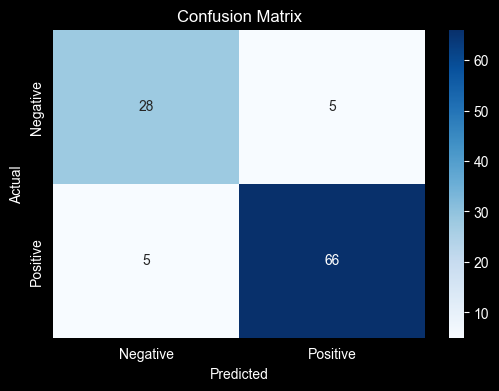

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Classification Report

In [115]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        33
           1       0.93      0.93      0.93        71

    accuracy                           0.90       104
   macro avg       0.89      0.89      0.89       104
weighted avg       0.90      0.90      0.90       104



In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

df = pd.read_csv("../data/diabetes_data_upload.csv")

df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

binary_columns = [
    "Polyuria", "Polydipsia", "sudden weight loss", "weakness",
    "Polyphagia", "Genital thrush", "visual blurring", "Itching",
    "Irritability", "delayed healing", "partial paresis",
    "muscle stiffness", "Alopecia", "Obesity"
]

for col in binary_columns:
    df[col] = df[col].map({"Yes": 1, "No": 0})

df["class"] = df["class"].map({"Positive": 1, "Negative": 0})

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

model = SVC(kernel="linear")

model.fit(X_train_scaled, y_train)

print("Model Ready!")

Model Ready!


In [117]:
print(model)
print(scaler)

SVC(kernel='linear')
StandardScaler()
